<a href="https://colab.research.google.com/github/rameelarustam47/flood-prediction-swat-valley-tensorflow/blob/main/Swat%20flood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported!
Mounted at /content/drive
All files loaded!
All resized to: (1857, 1857)

Flood label check:
Unique values: [0. 1.]
Flood pixels : 21271
No Flood pixels: 3425719
NaN pixels   : 1459

After removing NaN:
Total pixels : 3438927
Flood pixels : 21220
No Flood     : 3417707

Balancing data...
Before SMOTE:
Flood   : 21220
No Flood: 63660

After SMOTE:
Flood   : 63660
No Flood: 63660
Total   : 127320

Train: 101856
Test : 25464


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9785 - loss: 0.0560 - val_accuracy: 0.9989 - val_loss: 0.0033
Epoch 2/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9977 - loss: 0.0089 - val_accuracy: 0.9991 - val_loss: 0.0034
Epoch 3/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9981 - loss: 0.0071 - val_accuracy: 0.9994 - val_loss: 0.0020
Epoch 4/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9984 - loss: 0.0065 - val_accuracy: 0.9996 - val_loss: 0.0017
Epoch 5/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9982 - loss: 0.0059 - val_accuracy: 0.9996 - val_loss: 0.0021
Epoch 6/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9985 - loss: 0.0059 - val_accuracy: 0.9970 - val_loss: 0.0077
Epoch 7/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9985 - loss: 0.0058 - val_accuracy: 0.9995 - val_loss: 0.0022
Epoch 8/10
2547/2547 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9986 - loss: 0.005

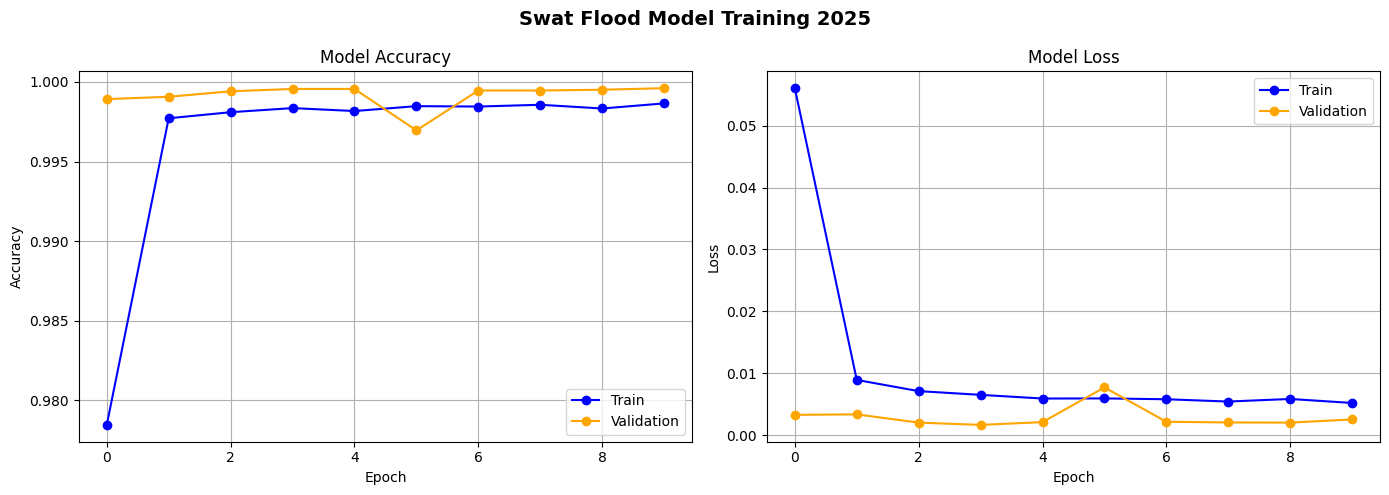


Test Accuracy : 99.91%
Test Loss     : 0.0037
796/796 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     12852
       Flood       1.00      1.00      1.00     12612

    accuracy                           1.00     25464
   macro avg       1.00      1.00      1.00     25464
weighted avg       1.00      1.00      1.00     25464



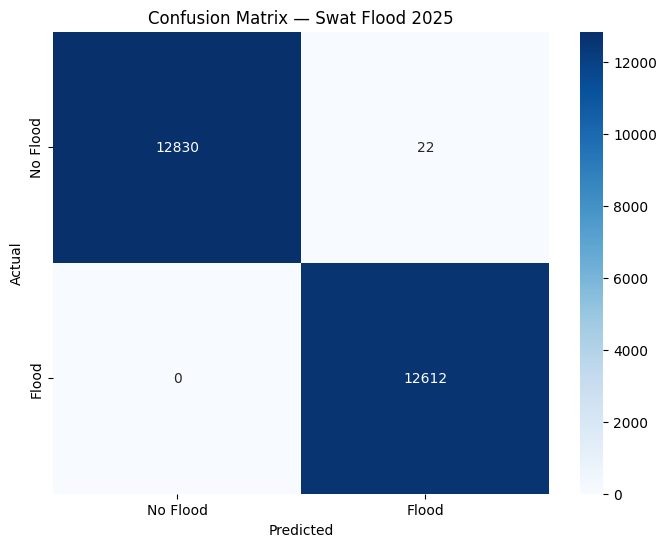


Model and scaler saved!
Project Complete!


In [2]:
# ============================================
# SWAT FLOOD PREDICTION - COMPLETE FIXED CODE
# ============================================

# STEP 1 - INSTALL AND IMPORT
!pip install rasterio --quiet
!pip install imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from skimage.transform import resize
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import tensorflow as tf
print("All libraries imported!")

# STEP 2 - MOUNT DRIVE
from google.colab import drive
drive.mount('/content/drive')

# STEP 3 - SET PATH
path = '/content/drive/MyDrive/swat_flood_2025/'

# STEP 4 - READ ALL FILES
with rasterio.open(path + 'Swat_SAR_Before_2025.tif') as src:
    sar_before = src.read(1).astype(float)
with rasterio.open(path + 'Swat_SAR_During_2025.tif') as src:
    sar_during = src.read(1).astype(float)
with rasterio.open(path + 'Swat_Flood_Extent_Fixed.tif') as src:
    flood_label = src.read(1).astype(float)
with rasterio.open(path + 'Swat_DEM_2025.tif') as src:
    dem = src.read(1).astype(float)
with rasterio.open(path + 'Swat_Slope_2025.tif') as src:
    slope = src.read(1).astype(float)
with rasterio.open(path + 'Swat_Rainfall_CHIRPS_2025.tif') as src:
    rainfall = src.read(1).astype(float)
print("All files loaded!")

# STEP 5 - RESIZE TO SAME SHAPE
target = sar_before.shape
sar_during  = resize(sar_during,  target)
flood_label = resize(flood_label, target)
dem         = resize(dem,         target)
slope       = resize(slope,       target)
rainfall    = resize(rainfall,    target)
print("All resized to:", target)

# STEP 6 - CHECK FLOOD LABEL
print("\nFlood label check:")
print("Unique values:", np.unique(flood_label[~np.isnan(flood_label)]))
print("Flood pixels :", (flood_label == 1).sum())
print("No Flood pixels:", (flood_label == 0).sum())
print("NaN pixels   :", np.isnan(flood_label).sum())

# STEP 7 - PREPARE DATA
X = np.column_stack([
    sar_before.flatten(),
    sar_during.flatten(),
    dem.flatten(),
    slope.flatten(),
    rainfall.flatten()
])
y = flood_label.flatten()

# ===== FIX NaN PROBLEM =====
# Remove ALL nan values from X and y
valid = (
    np.isfinite(X).all(axis=1) &
    np.isfinite(y) &
    (y != np.nan)
)
X = X[valid]
y = y[valid]

# Make binary labels
y = (y > 0.5).astype(int)

print("\nAfter removing NaN:")
print("Total pixels :", X.shape[0])
print("Flood pixels :", (y==1).sum())
print("No Flood     :", (y==0).sum())

# STEP 8 - BALANCE DATA WITH SMOTE
print("\nBalancing data...")

# First reduce no flood pixels to manageable size
X_flood   = X[y==1]
y_flood   = y[y==1]
X_noflood = X[y==0]
y_noflood = y[y==0]

# Reduce no flood to 3x flood count
n_noflood = min(len(X_flood) * 3, len(X_noflood))
X_noflood, y_noflood = resample(
    X_noflood, y_noflood,
    n_samples=n_noflood,
    random_state=42
)

# Combine
X = np.vstack([X_flood, X_noflood])
y = np.hstack([y_flood, y_noflood])

print("Before SMOTE:")
print("Flood   :", (y==1).sum())
print("No Flood:", (y==0).sum())

# Apply SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print("Flood   :", (y==1).sum())
print("No Flood:", (y==0).sum())
print("Total   :", X.shape[0])

# STEP 9 - SPLIT AND SCALE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("\nTrain:", X_train.shape[0])
print("Test :", X_test.shape[0])

# STEP 10 - BUILD MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        64, activation='relu',
        input_shape=(5,)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(
        32, activation='relu'
    ),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(
        16, activation='relu'
    ),
    tf.keras.layers.Dense(
        1, activation='sigmoid'
    )
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# STEP 11 - TRAIN MODEL
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print("Training complete!")

# STEP 12 - PLOT EPOCH RESULTS
print("\nEpoch Results:")
print("-" * 70)
for i in range(len(history.history['accuracy'])):
    print(
        f"Epoch {i+1:2d} | "
        f"Acc: {history.history['accuracy'][i]:.4f} | "
        f"Val Acc: {history.history['val_accuracy'][i]:.4f} | "
        f"Loss: {history.history['loss'][i]:.4f} | "
        f"Val Loss: {history.history['val_loss'][i]:.4f}"
    )

# STEP 13 - PLOT GRAPHS
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history.history['accuracy'],
             label='Train', color='blue', marker='o')
axes[0].plot(history.history['val_accuracy'],
             label='Validation', color='orange', marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history.history['loss'],
             label='Train', color='blue', marker='o')
axes[1].plot(history.history['val_loss'],
             label='Validation', color='orange', marker='o')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
plt.suptitle('Swat Flood Model Training 2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()

# STEP 14 - EVALUATE
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

predictions = (model.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(
    y_test, predictions,
    target_names=['No Flood','Flood']
))

# STEP 15 - CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Flood','Flood'],
    yticklabels=['No Flood','Flood']
)
plt.title('Confusion Matrix — Swat Flood 2025')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# STEP 16 - SAVE MODEL
import joblib
model.save('swat_flood_model.h5')
joblib.dump(scaler, 'scaler.pkl')
print("\nModel and scaler saved!")
print("Project Complete!")

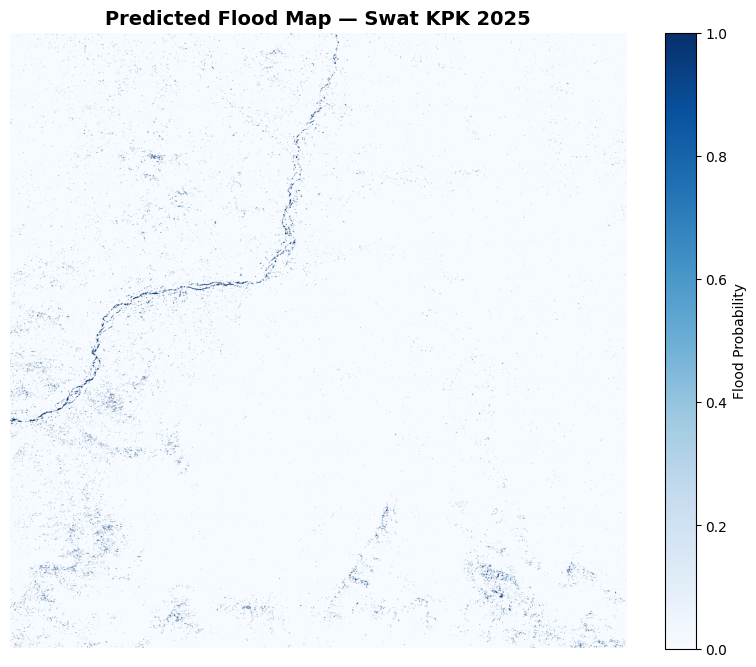

Flood prediction map saved!


In [ ]:
# Predict on entire Swat area
X_all = np.column_stack([
    sar_before.flatten(),
    sar_during.flatten(),
    dem.flatten(),
    slope.flatten(),
    rainfall.flatten()
])

valid_all = np.isfinite(X_all).all(axis=1)
flood_prob = np.zeros(X_all.shape[0])
flood_prob[valid_all] = model.predict(
    scaler.transform(X_all[valid_all]),
    verbose=0
).flatten()

flood_map = flood_prob.reshape(sar_before.shape)

plt.figure(figsize=(10, 8))
plt.imshow(flood_map, cmap='Blues')
plt.colorbar(label='Flood Probability')
plt.title('Predicted Flood Map — Swat KPK 2025',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.savefig('swat_flood_prediction_map.png', dpi=150)
plt.show()
print("Flood prediction map saved!")